In [1]:
!pip install kaggle -q

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d ramjidoolla/ipl-data-set
!unzip ipl-data-set.zip

Dataset URL: https://www.kaggle.com/datasets/ramjidoolla/ipl-data-set
License(s): other
100% 1.24M/1.24M [00:00<00:00, 2.36MB/s]

Archive:  ipl-data-set.zip
  inflating: Players.xlsx            
  inflating: deliveries.csv          
  inflating: matches.csv             
  inflating: most_runs_average_strikerate.csv  
  inflating: teams.csv               
  inflating: teamwise_home_and_away.csv  


In [3]:
import pandas as pd
df = pd.read_csv('/content/matches.csv')
print(df.shape)
print(df.columns.tolist())

(756, 18)
['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


In [4]:
print(df.isnull().sum())
print("\n")
print(df["winner"].value_counts())


id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [5]:
df = df.dropna(subset = ["winner"])
df = df.drop(columns = ["id", "date", "player_of_match", "umpire1", "umpire2", "umpire3"])


In [6]:
print(df.shape)
print(df.isnull().sum())

(752, 12)
Season            0
city              7
team1             0
team2             0
toss_winner       0
toss_decision     0
result            0
dl_applied        0
winner            0
win_by_runs       0
win_by_wickets    0
venue             0
dtype: int64


In [7]:
df["city"] = df["city"].fillna("unknown")
print(df.isnull().sum())

Season            0
city              0
team1             0
team2             0
toss_winner       0
toss_decision     0
result            0
dl_applied        0
winner            0
win_by_runs       0
win_by_wickets    0
venue             0
dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

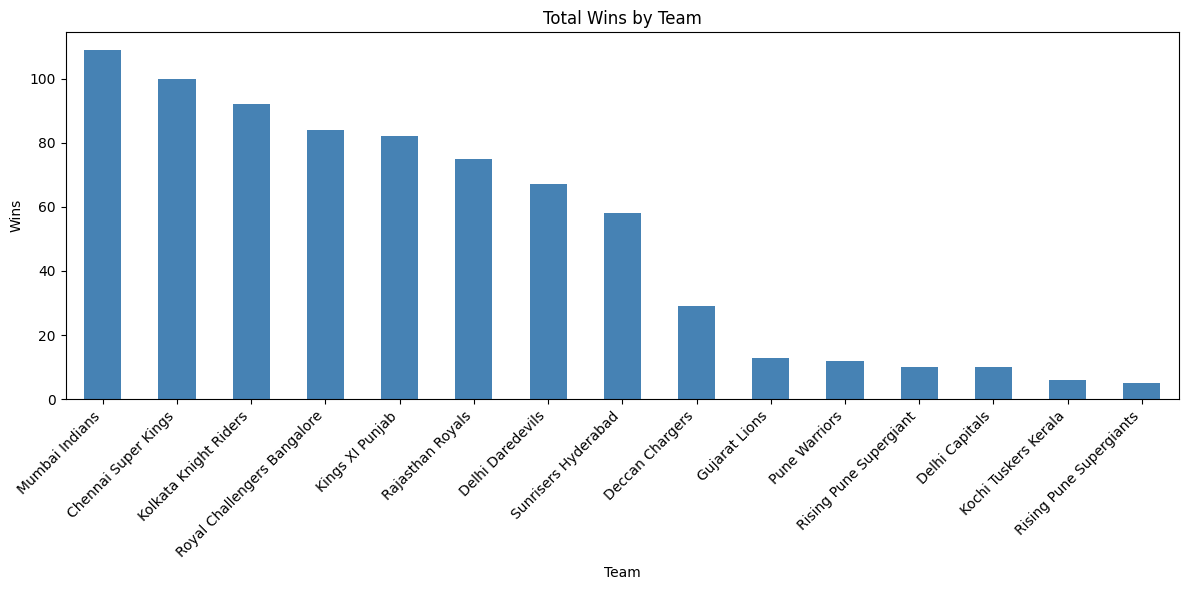

In [9]:
plt.figure(figsize=(12,6))
df["winner"].value_counts().plot(kind="bar", color = "steelblue")
plt.title("Total Wins by Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

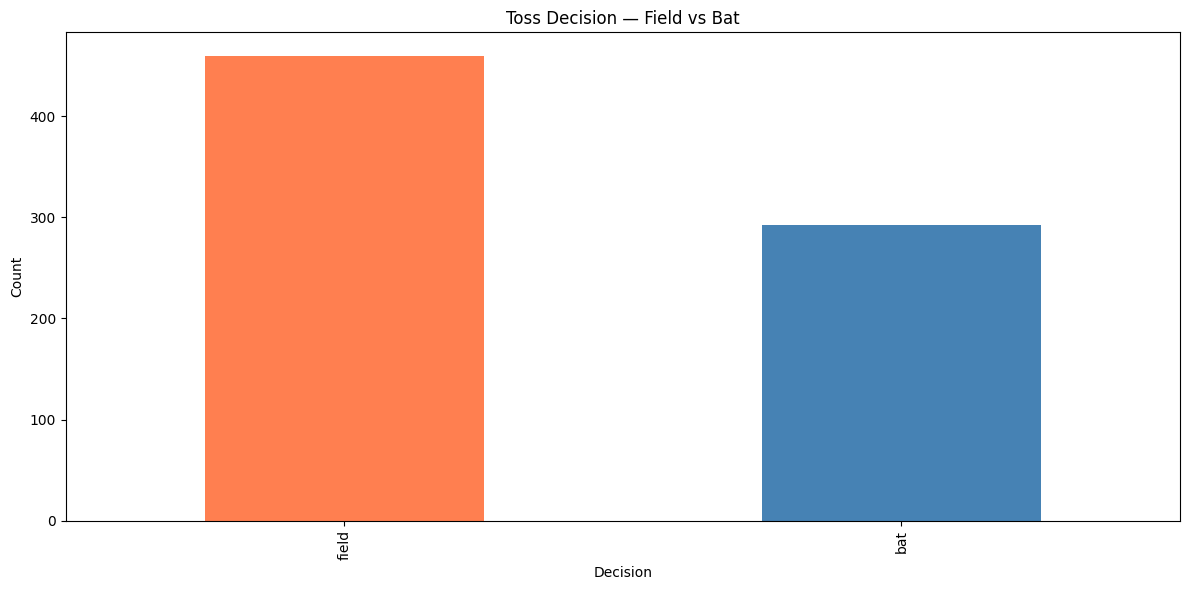

In [10]:
plt.figure(figsize=(12,6))
df["toss_decision"].value_counts().plot(kind="bar", color = ["coral", "steelblue"])
plt.title("Toss Decision — Field vs Bat")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
df["toss_win_match_win"] = df["toss_winner"] == df["winner"]
print(df["toss_win_match_win"].value_counts())
print("\nToss winner also won the match:",
      round(df["toss_win_match_win"].mean() * 100, 2), "%")

toss_win_match_win
True     393
False    359
Name: count, dtype: int64

Toss winner also won the match: 52.26 %


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["team1_enc"] = le.fit_transform(df["team1"])
df["team2_enc"] = le.fit_transform(df["team2"])
df["toss_winner_enc"] = le.fit_transform(df["toss_winner"])
df["venue_enc"] = le.fit_transform(df["venue"])
df["winner_enc"] = le.fit_transform(df["winner"])

df[["team1", "team1_enc", "team2", "team2_enc", "winner", "winner_enc"]].head()

,team1,team1_enc,team2,team2_enc,winner,winner_enc
0,Sunrisers Hyderabad,14,Royal Challengers Bangalore,13,Sunrisers Hyderabad,14
1,Mumbai Indians,8,Rising Pune Supergiant,11,Rising Pune Supergiant,11
2,Gujarat Lions,4,Kolkata Knight Riders,7,Kolkata Knight Riders,7
3,Rising Pune Supergiant,11,Kings XI Punjab,5,Kings XI Punjab,5
4,Royal Challengers Bangalore,13,Delhi Daredevils,3,Royal Challengers Bangalore,13


In [14]:
x= df[["team1_enc", "team2_enc", "venue_enc", "toss_winner_enc"]]
y = df["winner_enc"]

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
print(x_train.shape, x_test.shape)

(601, 4) (151, 4)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [18]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.271523178807947


In [19]:
df["team1"] == df["winner"]
print("Accuracy:", round(df["team1"] == df["winner"]).mean() * 100, "%")

Accuracy: 44.547872340425535 %


In [20]:
df["team2"] == df["winner"]
print("Accuracy:", round(df["team2"] == df["winner"]).mean() * 100, "%")

Accuracy: 55.452127659574465 %


In [21]:
df["team1_won"] = (df["team1"] == df["winner"]).astype(int)

In [22]:
df[["team1", "team2", "winner", "team1_won"]].head(10)

,team1,team2,winner,team1_won
0,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,1
1,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,0
2,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,0
3,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,0
4,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,1
5,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,0
6,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,0
7,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,0
8,Delhi Daredevils,Rising Pune Supergiant,Delhi Daredevils,1
9,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,0


In [23]:
x= df[["team1_enc", "team2_enc", "venue_enc", "toss_winner_enc"]]
y = df["team1_won"]

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
print(x_train.shape, x_test.shape)

(601, 4) (151, 4)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.543046357615894


In [28]:
pd.get_dummies(df["team1"])

,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
752,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
753,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
754,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [29]:
X = df[["team1", "team2", "venue", "toss_winner"]]
X = pd.get_dummies(X)

In [30]:
y = df["team1_won"]

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5562913907284768


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5364238410596026


In [36]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5496688741721855


In [37]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[54 28]
 [40 29]]


In [39]:
importance = model.feature_importances_
features = X.columns
print(features)
print(importance)

Index(['team1_Chennai Super Kings', 'team1_Deccan Chargers',
       'team1_Delhi Capitals', 'team1_Delhi Daredevils', 'team1_Gujarat Lions',
       'team1_Kings XI Punjab', 'team1_Kochi Tuskers Kerala',
       'team1_Kolkata Knight Riders', 'team1_Mumbai Indians',
       'team1_Pune Warriors', 'team1_Rajasthan Royals',
       'team1_Rising Pune Supergiant', 'team1_Rising Pune Supergiants',
       'team1_Royal Challengers Bangalore', 'team1_Sunrisers Hyderabad',
       'team2_Chennai Super Kings', 'team2_Deccan Chargers',
       'team2_Delhi Capitals', 'team2_Delhi Daredevils', 'team2_Gujarat Lions',
       'team2_Kings XI Punjab', 'team2_Kochi Tuskers Kerala',
       'team2_Kolkata Knight Riders', 'team2_Mumbai Indians',
       'team2_Pune Warriors', 'team2_Rajasthan Royals',
       'team2_Rising Pune Supergiant', 'team2_Rising Pune Supergiants',
       'team2_Royal Challengers Bangalore', 'team2_Sunrisers Hyderabad',
       'venue_ACA-VDCA Stadium', 'venue_Barabati Stadium',
       'v

In [40]:
import pandas as pd
feature_importances_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importances_df = feature_importances_df.sort_values('Importance', ascending=False)
print(feature_importances_df)

                                              Feature  Importance
77                   toss_winner_Kochi Tuskers Kerala    0.051864
12                      team1_Rising Pune Supergiants    0.051302
43                       venue_Holkar Cricket Stadium    0.045426
16                              team2_Deccan Chargers    0.034003
4                                 team1_Gujarat Lions    0.029898
..                                                ...         ...
45           venue_JSCA International Stadium Complex    0.000000
69  venue_Vidarbha Cricket Association Stadium, Ja...    0.000000
64                      venue_Sharjah Cricket Stadium    0.000000
63  venue_Shaheed Veer Narayan Singh International...    0.000000
55                              venue_OUTsurance Oval    0.000000

[86 rows x 2 columns]
